In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as units

In [2]:
image = 'dillon_extracting_files/dillon_fits/ztf_cutouts/ztf_cutouts_interp/ZTF18acpdvos_epoch_3.fits'

df = pd.read_csv('jacks-ztf-transients.csv')

In [3]:
import os
import pandas as pd

def get_transient_info(transient_name, epoch, df,
                       base_dir='dillon_extracting_files/dillon_fits/ztf_cutouts'):
    """
    Given a transient name and epoch, return:
      - interp image path
      - no_interp image path
      - source RA
      - source Dec
    """

    # build file paths
    interp_image = os.path.join(
        base_dir,
        'ztf_cutouts_interp',
        f'{transient_name}_epoch_{epoch}.fits'
    )

    no_interp_image = os.path.join(
        base_dir,
        'ztf_cutouts_no_interp',
        f'{transient_name}_epoch_{epoch}.fits'
    )

    # find matching row in dataframe
    match = df.loc[df['ZTFID'] == transient_name]

    if match.empty:
        raise ValueError(f'No transient named {transient_name} found in df.')

    # if there are duplicates, just use the first one
    source_ra = match.iloc[0]['RA']
    source_dec = match.iloc[0]['Dec']

    return {
        'interp_image': interp_image,
        'no_interp_image': no_interp_image,
        'source_ra': source_ra,
        'source_dec': source_dec
    }

In [4]:
def plot_transient(transient_name, epoch, df,
                   interp=True,
                   base_dir='dillon_extracting_files/dillon_fits/ztf_cutouts'):
    
    # choose folder
    folder = 'ztf_cutouts_interp' if interp else 'ztf_cutouts_no_interp'
    
    # build image path
    image = os.path.join(
        base_dir,
        folder,
        f'{transient_name}_epoch_{epoch}.fits'
    )
    
    # get RA/Dec from df
    match = df.loc[df['ZTFID'] == transient_name]
    if match.empty:
        raise ValueError(f'{transient_name} not found in df')
    
    source_ra = match.iloc[0]['RA']
    source_dec = match.iloc[0]['Dec']
    
    # open FITS
    hdu_list = fits.open(image)
    image_data = hdu_list[0].data
    wcs = WCS(hdu_list[0].header)
    
    # convert to SkyCoord
    sourceloc = SkyCoord(f'{source_ra} {source_dec}',
                         frame='fk5',
                         unit=(units.hourangle, units.deg))
    
    # world → pixel
    x, y = wcs.wcs_world2pix(sourceloc.ra.deg, sourceloc.dec.deg, 0)
    
    # plot
    plt.imshow(image_data, origin='lower', cmap='inferno')
    plt.scatter(x, y, color='red', s=100, marker='x')
    plt.title(f'{transient_name} | Epoch {epoch} | {"interp" if interp else "no_interp"}')
    plt.show()

a floating-point value was expected. [astropy.wcs.wcs]


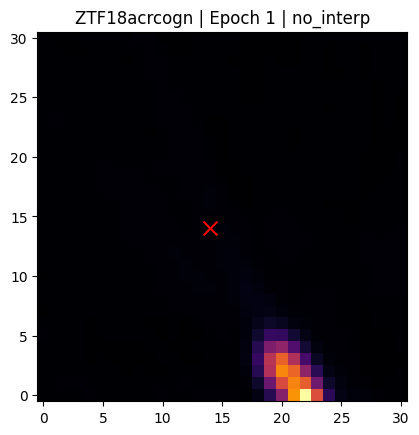

In [12]:
plot_transient('ZTF18acrcogn', 1, df, interp = False)

a floating-point value was expected. [astropy.wcs.wcs]


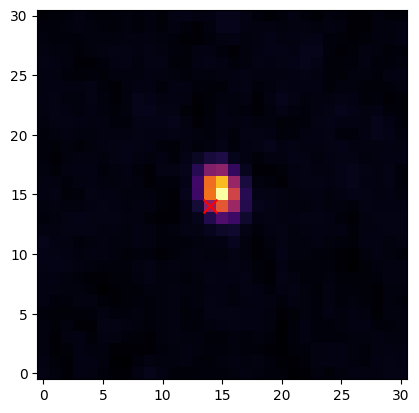

In [23]:


hdu_list = fits.open(image)
image_data = hdu_list[0].data
wcs = WCS(hdu_list[0].header)
source_ra = '10:06:50.87'
source_dec = '+01:41:34.0'

sourceloc = SkyCoord(f'{source_ra} {source_dec}',
                     frame='fk5',
                     unit=(units.hourangle, units.deg))

x, y = wcs.wcs_world2pix(sourceloc.ra.deg, sourceloc.dec.deg, 0)

plt.imshow(image_data, origin='lower', cmap='inferno')
plt.scatter(x, y, color='red', s=100, marker='x')
plt.show()